# ⭐ Day 70: GANs and Generative AI for Tabular Data
## Generating Synthetic Data with Deep Learning

🤖 **Day 70 of the 369-Day Python & AI Learning Path** 📊


Welcome to Day 70 of your Python & AI Learning Path! Today marks an exciting milestone as we venture into the cutting-edge realm of **Generative AI for tabular data**. While generative models like GANs have made headlines with stunning images and realistic text, their application to structured, tabular data is equally transformative—and often more immediately useful for data scientists and ML engineers.

Generative Adversarial Networks (GANs), introduced by Goodfellow et al. in 2014, revolutionized how we think about data generation. But standard GANs face unique challenges when applied to spreadsheets, databases, and structured datasets. Today, we'll explore specialized architectures like **CTGAN (Conditional Tabular GAN)** that overcome these hurdles, enabling us to create high-fidelity synthetic data that preserves statistical properties while protecting privacy.

Why does this matter? In real-world ML projects, we constantly face scenarios where data is scarce, sensitive, or imbalanced. Healthcare records cannot be freely shared. Financial datasets may be too small for robust model training. Customer data is bound by strict privacy regulations. Synthetic data generation offers an elegant solution: create unlimited, privacy-safe datasets that maintain the statistical integrity of the originals.

By the end of this notebook, you'll have hands-on experience training CTGAN models, evaluating synthetic data quality using statistical and privacy metrics, and leveraging generated data to improve model performance. This is not just theory—you'll build a complete pipeline that you can adapt to your own projects. Let's dive in! 🚀


## 📋 Table of Contents

1. [Introduction to Generative AI and Why It Matters for Tabular Data](#1-introduction-to-generative-ai-and-why-it-matters-for-tabular-data)
2. [Challenges of Applying Standard GANs to Tabular Data](#2-challenges-of-applying-standard-gans-to-tabular-data)
3. [Tabular GAN Architectures (CTGAN, TVAE, CopulaGAN overview)](#3-tabular-gan-architectures-ctgan-tvae-copulagan-overview)
4. [Installing and Using CTGAN](#4-installing-and-using-ctgan)
5. [Training a CTGAN on a Real Dataset](#5-training-a-ctgan-on-a-real-dataset)
6. [Evaluating Synthetic Data Quality](#6-evaluating-synthetic-data-quality)
7. [Visual Comparison: Real vs Synthetic Data Distributions](#7-visual-comparison-real-vs-synthetic-data-distributions)
8. [Using Synthetic Data for Model Training](#8-using-synthetic-data-for-model-training)
9. [Pros, Cons, and Best Practices](#9-pros-cons-and-best-practices-for-tabular-generative-models)
10. [When to Use Synthetic Data in Real ML Projects](#10-when-to-use-synthetic-data-in-real-ml-projects)
11. [🛠️ Hands-On Exercises](#-hands-on-exercises)
12. [Solutions & Key Insights](#-solutions--key-insights)


## 1. Introduction to Generative AI and Why It Matters for Tabular Data

Generative AI refers to models that learn the underlying distribution of training data and can generate new, statistically similar samples. While image generation (DALL-E, Stable Diffusion) and text generation (GPT, Claude) dominate headlines, **tabular data generation** is arguably more applicable to enterprise ML workflows.

### Key Applications:
- 🔒 **Privacy-Preserving Data Sharing**: Share synthetic datasets without exposing real customer information
- ⚖️ **Imbalanced Dataset Balancing**: Generate minority class samples to fix class imbalance
- 📈 **Data Augmentation**: Expand small datasets for more robust model training
- 🧪 **Stress Testing**: Create edge-case scenarios that may not exist in real data
- 🏥 **Healthcare & Finance**: Generate realistic patient or transaction data for research without compliance risks


## 2. Challenges of Applying Standard GANs to Tabular Data

Standard GANs designed for images face several obstacles with tabular data:

### 2.1 Mixed Data Types
Tabular datasets contain **continuous** (age, income), **categorical** (gender, city), and **ordinal** (education level) variables. Image GANs output continuous pixel values—adapting them to discrete categories requires specialized techniques.

### 2.2 Non-Gaussian Distributions
Real-world features often follow complex, multimodal distributions (e.g., income spikes at round numbers, age clustering). Standard GANs struggle with these irregular patterns.

### 2.3 Mode Collapse
GANs may generate only the most common patterns, missing rare but important combinations (e.g., high-income young professionals).

### 2.4 Correlation Preservation
Maintaining complex correlations between features (e.g., age and income, location and purchase behavior) is challenging without architectural modifications.

### 2.5 Evaluation Difficulty
Unlike images where humans can judge quality, evaluating tabular synthetic data requires sophisticated statistical metrics.


## 3. Tabular GAN Architectures (CTGAN, TVAE, CopulaGAN overview)

The **Synthetic Data Vault (SDV)** ecosystem provides state-of-the-art solutions:

### 3.1 CTGAN (Conditional Tabular GAN)
- Uses **mode-specific normalization** to handle non-Gaussian continuous variables
- Employs **conditional generator** to balance categorical distributions
- Applies **PacGAN** training to prevent mode collapse
- Best for: Complex datasets with mixed data types and imbalanced categories

### 3.2 TVAE (Tabular Variational Autoencoder)
- Based on Variational Autoencoders rather than adversarial training
- More stable training (no generator/discriminator balancing act)
- Often faster but may produce slightly less sharp distributions
- Best for: Quick prototyping and stable training requirements

### 3.3 CopulaGAN
- Combines GANs with **Copula models** to explicitly model feature correlations
- Excellent at preserving statistical relationships
- Best for: Datasets where correlation structure is critical

Today we focus on **CTGAN** as the most widely adopted and robust solution.


In [1]:
# Cell 1: Install required libraries
# Kaggle already includes most scientific libraries, so we only install SDV if needed.
# If SDV is missing and pip install fails on Kaggle, enable Internet in the notebook settings once.

import importlib
import subprocess
import sys

required_packages = {
    'sdv': 'sdv>=1.17.0'
}

for module_name, package_spec in required_packages.items():
    try:
        importlib.import_module(module_name)
        print(f'{module_name} is already available.')
    except ImportError:
        print(f'Installing {package_spec} ...')
        try:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package_spec])
        except subprocess.CalledProcessError as exc:
            raise RuntimeError(
                'SDV is not installed and pip could not download it. On Kaggle, turn Internet on once in the notebook settings and rerun this cell.'
            ) from exc

print("✅ All dependencies installed successfully!")


Installing sdv>=1.17.0 ...
✅ All dependencies installed successfully!


In [2]:
# Cell 2: Import libraries
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# SDV imports for synthetic data generation
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata
from sdv.evaluation.single_table import evaluate_quality

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

IN_KAGGLE = Path('/kaggle/input').exists()
WORKING_DIR = Path('/kaggle/working') if IN_KAGGLE else Path.cwd()
print(f'Running in Kaggle: {IN_KAGGLE}')
print("✅ Libraries imported successfully!")


Running in Kaggle: False
✅ Libraries imported successfully!


In [3]:
# Cell 3: Load and explore the dataset
# We'll use the Titanic dataset as our tabular example.
# Kaggle notebooks often run without outbound internet, so we try Kaggle/local paths first.
# It has mixed data types: continuous (Age, Fare), categorical (Sex, Embarked), binary (Survived)

dataset_candidates = [
    Path('/kaggle/input/titanic/train.csv'),
    Path('/kaggle/input/titanic-dataset/Titanic-Dataset.csv'),
    Path('/kaggle/input/titanic-passengers/train.csv'),
    Path('034_ai/train.csv')
]

dataset_source = None
df_real = None

for candidate in dataset_candidates:
    if candidate.exists():
        df_real = pd.read_csv(candidate)
        dataset_source = str(candidate)
        break

if df_real is None:
    url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
    try:
        df_real = pd.read_csv(url)
        dataset_source = url
    except Exception as exc:
        raise FileNotFoundError(
            'Titanic dataset not found. On Kaggle, add a Titanic dataset as notebook input or enable Internet for the fallback URL.'
        ) from exc

# Display basic information
print(f'📁 Dataset source: {dataset_source}')
print("📊 Dataset Shape:", df_real.shape)
print("\n🔍 First 5 rows:")
print(df_real.head())

print("\n📋 Data Types:")
print(df_real.dtypes)

print("\n📈 Basic Statistics:")
print(df_real.describe())


📁 Dataset source: https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
📊 Dataset Shape: (891, 12)

🔍 First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 31

In [8]:
# Cell 4: Data preprocessing for CTGAN
# CTGAN works best with clean, well-prepared data
# We need to handle missing values and select relevant features

# Select a subset of columns for clarity
columns_to_use = ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
missing_columns = [col for col in columns_to_use if col not in df_real.columns]
if missing_columns:
    raise ValueError(f'Required columns are missing from the dataset: {missing_columns}')

df_processed = df_real[columns_to_use].copy()

# Handle missing values
df_processed['Age'] = df_processed['Age'].fillna(df_processed['Age'].median())
df_processed['Fare'] = df_processed['Fare'].fillna(df_processed['Fare'].median())
df_processed['Embarked'] = df_processed['Embarked'].fillna(df_processed['Embarked'].mode()[0])

# Convert data types for better handling
categorical_columns = ['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']
for col in categorical_columns:
    df_processed[col] = df_processed[col].astype('object')

print("✅ Preprocessing complete!")
print(f"Final dataset shape: {df_processed.shape}")
print(f"Missing values: {df_processed.isnull().sum().sum()}")
print("\n📋 Processed Data Types:")
print(df_processed.dtypes)


✅ Preprocessing complete!
Final dataset shape: (891, 8)
Missing values: 0

📋 Processed Data Types:
Survived     object
Pclass       object
Sex          object
Age         float64
SibSp        object
Parch        object
Fare        float64
Embarked     object
dtype: object


## 4. Installing and Using CTGAN (Conditional Tabular GAN)

CTGAN requires metadata configuration to understand which columns are categorical vs. continuous. The SDV library automates this detection, but we can also define it manually for precision.


In [9]:
# Cell 5: Configure metadata for CTGAN
# Metadata tells CTGAN which columns are categorical vs numerical
# This is crucial for proper mode-specific normalization

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=df_processed)

# Verify auto-detected metadata
print("🔍 Auto-detected Metadata:")
print(metadata.to_dict())


🔍 Auto-detected Metadata:
{'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1', 'columns': {'Survived': {'sdtype': 'categorical'}, 'Pclass': {'sdtype': 'categorical'}, 'Sex': {'sdtype': 'categorical'}, 'Age': {'sdtype': 'numerical'}, 'SibSp': {'sdtype': 'categorical'}, 'Parch': {'sdtype': 'categorical'}, 'Fare': {'sdtype': 'numerical'}, 'Embarked': {'sdtype': 'categorical'}}}


In [10]:
# Cell 6: Initialize and configure CTGAN synthesizer
# Key hyperparameters:
# - epochs: Training iterations (more = better quality but slower)
# - batch_size: Training batch size
# - generator_dim: Hidden layer sizes for generator
# - discriminator_dim: Hidden layer sizes for discriminator
# - embedding_dim: Dimension for categorical embeddings

ctgan_epochs = 100 if IN_KAGGLE else 300
ctgan_batch_size = min(500, len(df_processed))
if ctgan_batch_size % 2 != 0:
    ctgan_batch_size -= 1
ctgan_batch_size = max(ctgan_batch_size, 2)

synthesizer = CTGANSynthesizer(
    metadata,
    epochs=ctgan_epochs,     # Kaggle-friendly default runtime
    batch_size=ctgan_batch_size,
    generator_dim=(256, 256), # Generator hidden layers
    discriminator_dim=(256, 256), # Discriminator hidden layers
    verbose=True
)

print("✅ CTGAN synthesizer initialized!")
print("Configuration:")
print(f"  Epochs: {synthesizer.epochs}")
print(f"  Batch Size: {synthesizer.batch_size}")
print(f"  Generator Dimensions: {synthesizer.generator_dim}")
print(f"  Discriminator Dimensions: {synthesizer.discriminator_dim}")


✅ CTGAN synthesizer initialized!
Configuration:
  Epochs: 300
  Batch Size: 500
  Generator Dimensions: (256, 256)
  Discriminator Dimensions: (256, 256)


## 5. Training a CTGAN on a Real Dataset

Training CTGAN involves a minimax game between the Generator (creates fake data) and Discriminator (tries to detect fakes). For tabular data, CTGAN adds:
- **Mode-specific normalization**: Transforms continuous variables into multimodal Gaussian mixtures
- **Conditional vector**: Ensures balanced categorical sampling
- **PacGAN**: Uses multiple samples per discriminator evaluation to prevent mode collapse


In [11]:
# Cell 7: Train the CTGAN model
# This may take 2-5 minutes depending on your hardware
# The model learns the joint probability distribution of all features

print("🚀 Starting CTGAN training...")
print("⏳ This may take a few minutes. Grab a coffee! ☕")

synthesizer.fit(df_processed)

print("✅ Training complete! Model has learned the data distribution.")


🚀 Starting CTGAN training...
⏳ This may take a few minutes. Grab a coffee! ☕


Gen. (-00.58) | Discrim. (-00.08): 100%|██████████| 300/300 [01:15<00:00,  3.98it/s]

✅ Training complete! Model has learned the data distribution.


In [12]:
# Cell 8: Generate synthetic data
# We can generate any number of samples—here we match the original dataset size
# But you could generate 10x, 100x, or any amount needed

num_samples = len(df_processed)
df_synthetic = synthesizer.sample(num_rows=num_samples)

print(f"✅ Generated {len(df_synthetic)} synthetic samples")
print("\n🔍 First 5 synthetic rows:")
print(df_synthetic.head())

print("\n📋 Synthetic Data Types:")
print(df_synthetic.dtypes)


✅ Generated 891 synthetic samples

🔍 First 5 synthetic rows:
  Survived Pclass     Sex    Age SibSp Parch     Fare Embarked
0        0      1    male  33.97     0     0  42.0318        S
1        1      2  female  27.70     0     0  72.3339        S
2        1      1  female  31.78     3     0   0.7706        S
3        0      2    male  23.15     0     1   0.0000        C
4        0      2  female  29.44     1     1   0.0000        C

📋 Synthetic Data Types:
Survived     object
Pclass       object
Sex          object
Age         float64
SibSp        object
Parch        object
Fare        float64
Embarked     object
dtype: object


## 6. Evaluating Synthetic Data Quality

Quality evaluation is critical. We assess three dimensions:
1. **Fidelity**: Do distributions match? (KS test, Chi-square)
2. **Utility**: Can models trained on synthetic data perform well on real data?
3. **Privacy**: Is real data protected? (Distance to closest record)


In [13]:
# Cell 9: Statistical similarity evaluation using SDV's built-in metrics
# This computes column shapes, column pair trends, and overall quality score

quality_report = evaluate_quality(
    real_data=df_processed,
    synthetic_data=df_synthetic,
    metadata=metadata
)

print("📊 Synthetic Data Quality Report")
print("=" * 50)
print(f"Overall Quality Score: {quality_report.get_score():.3f} (1.0 = perfect)")
print("\n📈 Column Shapes (Distribution Similarity):")
print(quality_report.get_details(property_name='Column Shapes'))
print("\n🔗 Column Pair Trends (Correlation Similarity):")
print(quality_report.get_details(property_name='Column Pair Trends'))


Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 8/8 [00:00<00:00, 192.20it/s]|
Column Shapes Score: 84.01%

(2/2) Evaluating Column Pair Trends: |██████████| 28/28 [00:00<00:00, 28.78it/s]|
Column Pair Trends Score: 79.2%

Overall Score (Average): 81.6%

📊 Synthetic Data Quality Report
Overall Quality Score: 0.816 (1.0 = perfect)

📈 Column Shapes (Distribution Similarity):
     Column        Metric     Score
0  Survived  TVComplement  0.985410
1    Pclass  TVComplement  0.964085
2       Sex  TVComplement  0.861953
3       Age  KSComplement  0.847363
4     SibSp  TVComplement  0.827160
5     Parch  TVComplement  0.876543
6      Fare  KSComplement  0.416386
7  Embarked  TVComplement  0.941639

🔗 Column Pair Trends (Correlation Similarity):
    Column 1  Column 2                 Metric     Score  Real Correlation  \
0   Survived    Pclass  ContingencySimilarity  0.809203               NaN   
1   Survived       Sex  ContingencySimilarity  0.768799               NaN   
2

In [14]:
# Cell 10: Custom statistical comparison
# Compare basic statistics between real and synthetic data

# For continuous columns
continuous_cols = ['Age', 'Fare']
comparison_stats = pd.DataFrame({
    'Real_Mean': df_processed[continuous_cols].mean(),
    'Synthetic_Mean': df_synthetic[continuous_cols].mean(),
    'Real_Std': df_processed[continuous_cols].std(),
    'Synthetic_Std': df_synthetic[continuous_cols].std(),})
comparison_stats['Mean_Diff_%'] = abs(comparison_stats['Real_Mean'] - comparison_stats['Synthetic_Mean']) / comparison_stats['Real_Mean'] * 100
comparison_stats['Std_Diff_%'] = abs(comparison_stats['Real_Std'] - comparison_stats['Synthetic_Std']) / comparison_stats['Real_Std'] * 100

print("📊 Statistical Comparison (Continuous Features)")
print("=" * 60)
print(comparison_stats.round(3))

# For categorical columns
print("\n📊 Categorical Distribution Comparison (Top 3 categories)")
print("=" * 60)
cat_cols = ['Survived', 'Pclass', 'Sex', 'Embarked']
for col in cat_cols:
    real_dist = df_processed[col].value_counts(normalize=True).head(3)
    synth_dist = df_synthetic[col].value_counts(normalize=True).head(3)
    print(f"\n{col}:")
    print(f"  Real:     {dict(real_dist.round(3))}")
    print(f"  Synthetic: {dict(synth_dist.round(3))}")


📊 Statistical Comparison (Continuous Features)
      Real_Mean  Synthetic_Mean  Real_Std  Synthetic_Std  Mean_Diff_%  \
Age      29.362          28.564    13.020         16.918        2.717   
Fare     32.204          10.484    49.693         22.567       67.446   

      Std_Diff_%  
Age       29.945  
Fare      54.589  

📊 Categorical Distribution Comparison (Top 3 categories)

Survived:
  Real:     {0: np.float64(0.616), 1: np.float64(0.384)}
  Synthetic: {0: np.float64(0.602), 1: np.float64(0.398)}

Pclass:
  Real:     {3: np.float64(0.551), 1: np.float64(0.242), 2: np.float64(0.207)}
  Synthetic: {3: np.float64(0.521), 1: np.float64(0.278), 2: np.float64(0.201)}

Sex:
  Real:     {'male': np.float64(0.648), 'female': np.float64(0.352)}
  Synthetic: {'male': np.float64(0.51), 'female': np.float64(0.49)}

Embarked:
  Real:     {'S': np.float64(0.725), 'C': np.float64(0.189), 'Q': np.float64(0.086)}
  Synthetic: {'S': np.float64(0.667), 'C': np.float64(0.222), 'Q': np.float64(0.111)}

In [15]:
# Cell 11: Privacy metrics
# Check if synthetic data is too close to real data (privacy leakage)
# or too far (utility loss)

from scipy.spatial.distance import cdist

# Encode real and synthetic categorical variables with a shared mapping.
def encode_pairwise(real_df, synthetic_df):
    real_encoded = real_df.copy()
    synthetic_encoded = synthetic_df.copy()

    categorical_cols = sorted(
        set(real_encoded.select_dtypes(include=['category', 'object']).columns)
        | set(synthetic_encoded.select_dtypes(include=['category', 'object']).columns)
    )

    for col in categorical_cols:
        categories = pd.Index(real_encoded[col].astype(str)).union(pd.Index(synthetic_encoded[col].astype(str)))
        mapping = {category: idx for idx, category in enumerate(categories)}
        real_encoded[col] = real_encoded[col].astype(str).map(mapping).astype(float)
        synthetic_encoded[col] = synthetic_encoded[col].astype(str).map(mapping).astype(float)

    return real_encoded, synthetic_encoded

real_encoded, synthetic_encoded = encode_pairwise(df_processed, df_synthetic)

# Normalize for fair distance calculation
scaler = StandardScaler()
real_scaled = scaler.fit_transform(real_encoded)
synthetic_scaled = scaler.transform(synthetic_encoded)

# Calculate nearest neighbor distances
# DCR: Distance to Closest Record (lower = privacy risk)
distances = cdist(synthetic_scaled, real_scaled, metric='euclidean')
dcr = distances.min(axis=1)

print("🔒 Privacy Metrics")
print("=" * 40)
print(f"Mean Distance to Closest Record (DCR): {dcr.mean():.4f}")
print(f"Median DCR: {np.median(dcr):.4f}")
print(f"Min DCR: {dcr.min():.4f} (lower = potential privacy leak)")
print(f"Max DCR: {dcr.max():.4f}")
print(f"Records with DCR < 0.1 (possible duplicates): {(dcr < 0.1).sum()}")
print("\n💡 Interpretation: Higher DCR = better privacy. DCR near 0 suggests exact copies.")


🔒 Privacy Metrics
Mean Distance to Closest Record (DCR): 0.9285
Median DCR: 0.7119
Min DCR: 0.0131 (lower = potential privacy leak)
Max DCR: 3.5098
Records with DCR < 0.1 (possible duplicates): 59

💡 Interpretation: Higher DCR = better privacy. DCR near 0 suggests exact copies.


## 7. Visual Comparison: Real vs Synthetic Data Distributions

Visual inspection is crucial for understanding where the model succeeds and where it struggles. We compare histograms, boxplots, and correlation matrices.


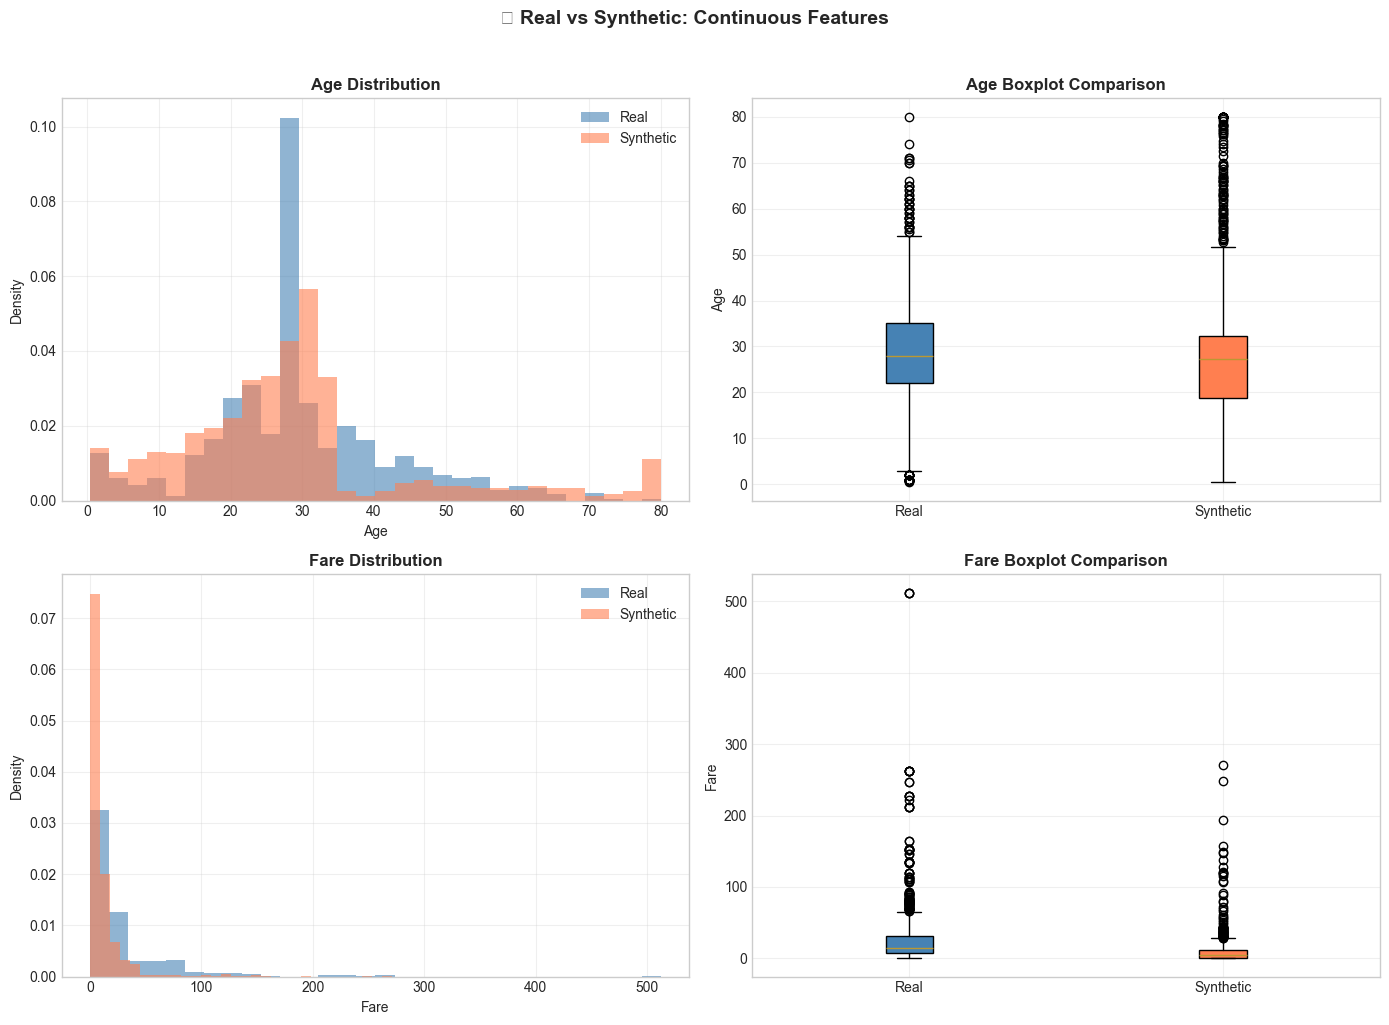

✅ Distribution plots generated!


In [16]:
# Cell 12: Distribution comparison - Continuous features
# Side-by-side histograms and KDE plots

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
continuous_features = ['Age', 'Fare']

for idx, feature in enumerate(continuous_features):
    # Histogram
    ax = axes[idx, 0]
    ax.hist(df_processed[feature], bins=30, alpha=0.6, label='Real', density=True, color='steelblue')
    ax.hist(df_synthetic[feature], bins=30, alpha=0.6, label='Synthetic', density=True, color='coral')
    ax.set_title(f'{feature} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Boxplot
    ax = axes[idx, 1]
    data_to_plot = [df_processed[feature].dropna(), df_synthetic[feature].dropna()]
    bp = ax.boxplot(data_to_plot, labels=['Real', 'Synthetic'], patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('coral')
    ax.set_title(f'{feature} Boxplot Comparison', fontsize=12, fontweight='bold')
    ax.set_ylabel(feature)
    ax.grid(True, alpha=0.3)

plt.suptitle('📊 Real vs Synthetic: Continuous Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("✅ Distribution plots generated!")


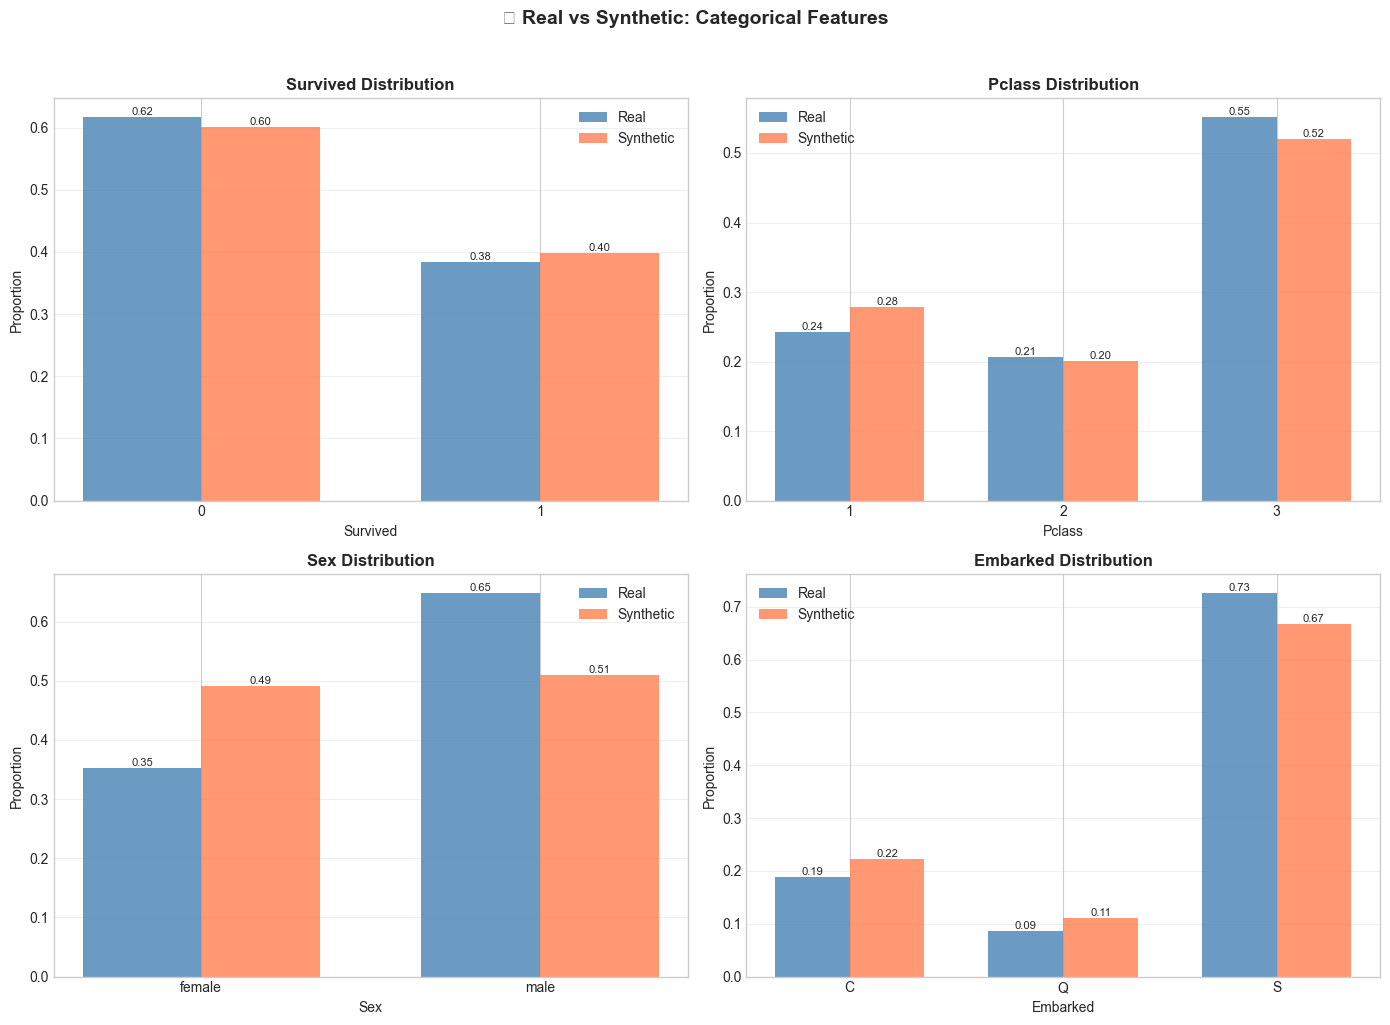

In [17]:
# Cell 13: Categorical feature comparison
# Bar charts for categorical distributions

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
categorical_features = ['Survived', 'Pclass', 'Sex', 'Embarked']

for idx, feature in enumerate(categorical_features):
    ax = axes[idx // 2, idx % 2]
    
    real_counts = df_processed[feature].value_counts(normalize=True).sort_index()
    synth_counts = df_synthetic[feature].value_counts(normalize=True).sort_index()
    all_categories = real_counts.index.union(synth_counts.index)
    real_counts = real_counts.reindex(all_categories, fill_value=0)
    synth_counts = synth_counts.reindex(all_categories, fill_value=0)
    
    x = np.arange(len(all_categories))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, real_counts.values, width, label='Real', color='steelblue', alpha=0.8)
    bars2 = ax.bar(x + width/2, synth_counts.values, width, label='Synthetic', color='coral', alpha=0.8)
    
    ax.set_title(f'{feature} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('Proportion')
    ax.set_xticks(x)
    ax.set_xticklabels([str(category) for category in all_categories])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('📊 Real vs Synthetic: Categorical Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


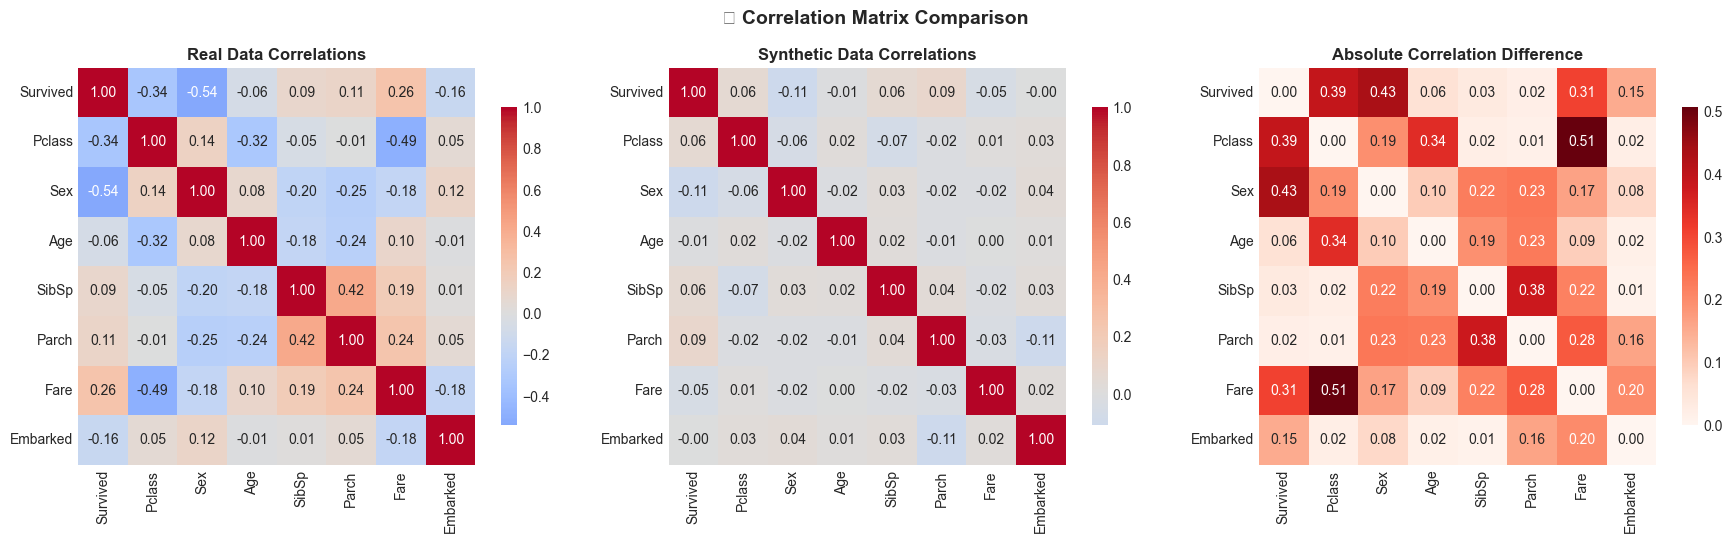

📊 Mean Absolute Correlation Difference: 0.1812
💡 Lower values indicate better correlation preservation.


In [18]:
# Cell 14: Correlation matrix comparison
# Preserving correlations is critical for utility

# Encode categorical variables for correlation calculation
df_real_encoded, df_synth_encoded = encode_pairwise(df_processed, df_synthetic)

# Calculate correlation matrices
corr_real = df_real_encoded.corr()
corr_synth = df_synth_encoded.corr()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Real data correlation
sns.heatmap(corr_real, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Real Data Correlations', fontsize=12, fontweight='bold')

# Synthetic data correlation
sns.heatmap(corr_synth, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Synthetic Data Correlations', fontsize=12, fontweight='bold')

# Difference
corr_diff = abs(corr_real - corr_synth)
sns.heatmap(corr_diff, annot=True, fmt='.2f', cmap='Reds', 
            square=True, ax=axes[2], cbar_kws={'shrink': 0.8})
axes[2].set_title('Absolute Correlation Difference', fontsize=12, fontweight='bold')

plt.suptitle('🔗 Correlation Matrix Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print correlation preservation metric
mean_corr_diff = corr_diff.values[np.triu_indices_from(corr_diff.values, k=1)].mean()
print(f"📊 Mean Absolute Correlation Difference: {mean_corr_diff:.4f}")
print("💡 Lower values indicate better correlation preservation.")


## 8. Using Synthetic Data for Model Training (Data Augmentation)

The ultimate test: can we train a model on synthetic data and have it perform well on real data? We'll compare three scenarios:
1. Train on Real, Test on Real (baseline)
2. Train on Synthetic, Test on Real (utility test)
3. Train on Real + Synthetic, Test on Real (augmentation test)


In [19]:
# Cell 15: Prepare data for machine learning
# We'll predict Survival using the other features

def prepare_ml_datasets(real_df, synthetic_df, target='Survived'):
    """Prepare real and synthetic data with consistent encodings and feature order."""
    real_ml = real_df.copy()
    synth_ml = synthetic_df.copy()

    categorical_cols = sorted(
        set(real_ml.select_dtypes(include=['category', 'object']).columns)
        | set(synth_ml.select_dtypes(include=['category', 'object']).columns)
    )

    for col in categorical_cols:
        if col == target:
            continue
        categories = pd.Index(real_ml[col].astype(str)).union(pd.Index(synth_ml[col].astype(str)))
        mapping = {category: idx for idx, category in enumerate(categories)}
        real_ml[col] = real_ml[col].astype(str).map(mapping).astype(float)
        synth_ml[col] = synth_ml[col].astype(str).map(mapping).astype(float)

    real_ml[target] = real_ml[target].astype(int)
    synth_ml[target] = synth_ml[target].astype(int)

    feature_cols = [col for col in real_ml.columns if col != target]
    X_real = real_ml[feature_cols].astype(float)
    y_real = real_ml[target]
    X_synth = synth_ml[feature_cols].astype(float)
    y_synth = synth_ml[target]

    return X_real, y_real, X_synth, y_synth

# Prepare real data
X_real, y_real, X_synth, y_synth = prepare_ml_datasets(df_processed, df_synthetic)

# Split real data into train and test
X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_real, y_real, test_size=0.3, random_state=42, stratify=y_real
)

print("✅ Data prepared for machine learning experiments!")
print(f"Real training set: {X_train_real.shape}")
print(f"Real test set: {X_test_real.shape}")
print(f"Synthetic training set: {X_synth.shape}")


✅ Data prepared for machine learning experiments!
Real training set: (623, 7)
Real test set: (268, 7)
Synthetic training set: (891, 7)


🤖 Model Performance Comparison
                     AUC  Accuracy
Real Only         0.8410    0.7910
Synthetic Only    0.5710    0.5821
Real + Synthetic  0.8205    0.7873


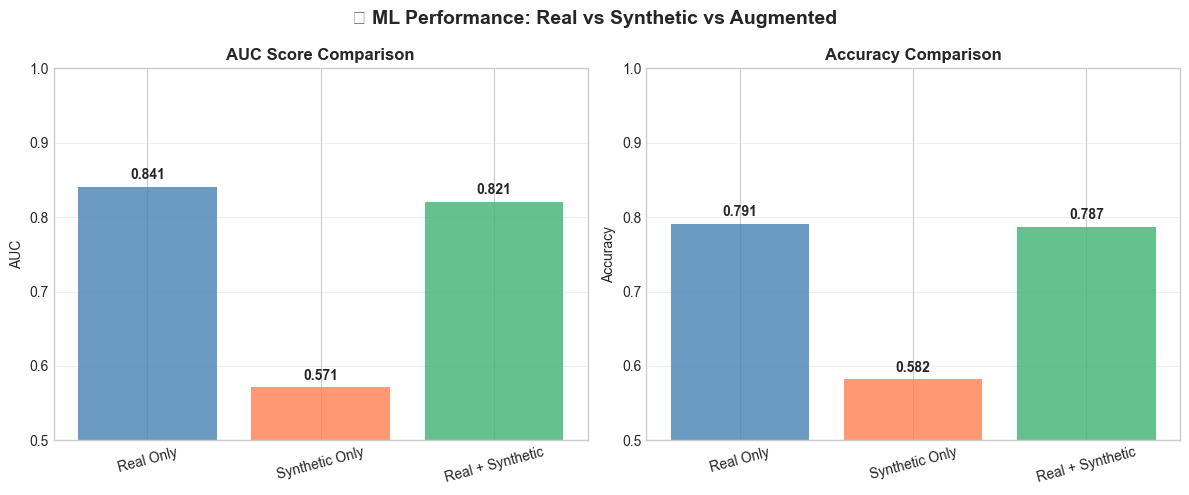

In [20]:
# Cell 16: Train models and compare performance
# Scenario 1: Real only (baseline)
# Scenario 2: Synthetic only
# Scenario 3: Real + Synthetic (augmented)

results = {}

# Scenario 1: Baseline - Train on Real, Test on Real
rf_real = RandomForestClassifier(n_estimators=100, random_state=42)
rf_real.fit(X_train_real, y_train_real)
y_pred_real = rf_real.predict(X_test_real)
auc_real = roc_auc_score(y_test_real, rf_real.predict_proba(X_test_real)[:, 1])
acc_real = accuracy_score(y_test_real, y_pred_real)
results['Real Only'] = {'AUC': auc_real, 'Accuracy': acc_real}

# Scenario 2: Synthetic only - Train on Synthetic, Test on Real
rf_synth = RandomForestClassifier(n_estimators=100, random_state=42)
rf_synth.fit(X_synth, y_synth)
y_pred_synth = rf_synth.predict(X_test_real)
auc_synth = roc_auc_score(y_test_real, rf_synth.predict_proba(X_test_real)[:, 1])
acc_synth = accuracy_score(y_test_real, y_pred_synth)
results['Synthetic Only'] = {'AUC': auc_synth, 'Accuracy': acc_synth}

# Scenario 3: Augmented - Train on Real + Synthetic, Test on Real
X_augmented = pd.concat([X_train_real, X_synth], ignore_index=True)
y_augmented = pd.concat([y_train_real, y_synth], ignore_index=True)
rf_aug = RandomForestClassifier(n_estimators=100, random_state=42)
rf_aug.fit(X_augmented, y_augmented)
y_pred_aug = rf_aug.predict(X_test_real)
auc_aug = roc_auc_score(y_test_real, rf_aug.predict_proba(X_test_real)[:, 1])
acc_aug = accuracy_score(y_test_real, y_pred_aug)
results['Real + Synthetic'] = {'AUC': auc_aug, 'Accuracy': acc_aug}

# Display results
print("🤖 Model Performance Comparison")
print("=" * 50)
results_df = pd.DataFrame(results).T
print(results_df.round(4))

# Visualization
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
scenarios = list(results.keys())
auc_scores = [results[s]['AUC'] for s in scenarios]
acc_scores = [results[s]['Accuracy'] for s in scenarios]
colors = ['steelblue', 'coral', 'mediumseagreen']
ax[0].bar(scenarios, auc_scores, color=colors, alpha=0.8)
ax[0].set_title('AUC Score Comparison', fontweight='bold')
ax[0].set_ylabel('AUC')
ax[0].set_ylim(0.5, 1.0)
for i, v in enumerate(auc_scores):
    ax[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
ax[0].grid(True, alpha=0.3, axis='y')
ax[0].tick_params(axis='x', rotation=15)
ax[1].bar(scenarios, acc_scores, color=colors, alpha=0.8)
ax[1].set_title('Accuracy Comparison', fontweight='bold')
ax[1].set_ylabel('Accuracy')
ax[1].set_ylim(0.5, 1.0)
for i, v in enumerate(acc_scores):
    ax[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
ax[1].grid(True, alpha=0.3, axis='y')
ax[1].tick_params(axis='x', rotation=15)
plt.suptitle('📈 ML Performance: Real vs Synthetic vs Augmented', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


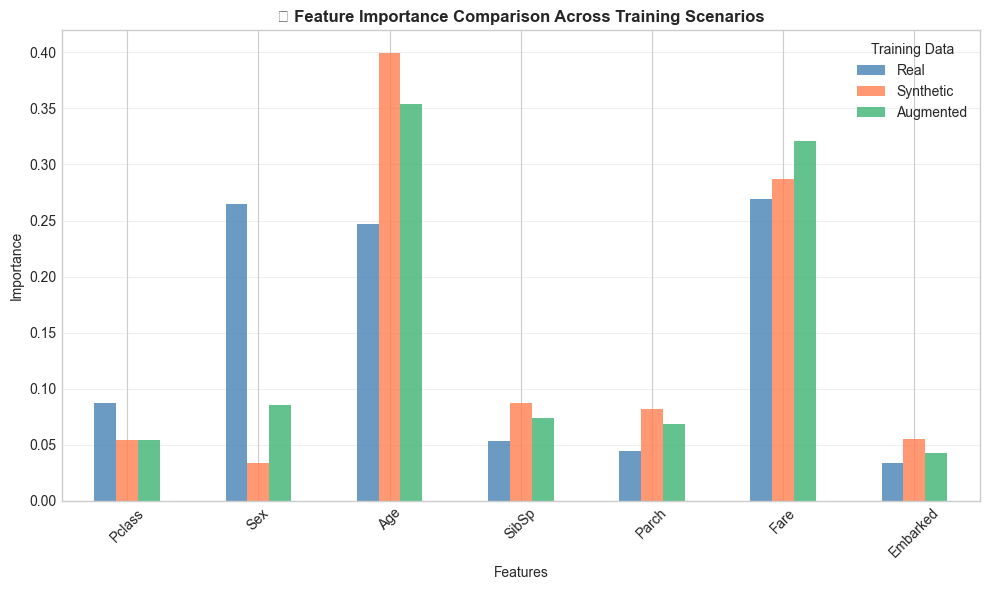

✅ Feature importance comparison complete!

📊 Feature Importance Values:
            Real  Synthetic  Augmented
Pclass    0.0875     0.0548     0.0543
Sex       0.2647     0.0339     0.0856
Age       0.2470     0.3995     0.3540
SibSp     0.0534     0.0878     0.0740
Parch     0.0443     0.0817     0.0684
Fare      0.2693     0.2869     0.3208
Embarked  0.0338     0.0555     0.0429


In [21]:
# Cell 17: Feature importance comparison
# Do models trained on synthetic data learn similar patterns?

importance_real = pd.Series(rf_real.feature_importances_, index=X_train_real.columns, name='Real')
importance_synth = pd.Series(rf_synth.feature_importances_, index=X_synth.columns, name='Synthetic')
importance_aug = pd.Series(rf_aug.feature_importances_, index=X_augmented.columns, name='Augmented')

importance_df = pd.concat([importance_real, importance_synth, importance_aug], axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
importance_df.plot(kind='bar', ax=ax, color=['steelblue', 'coral', 'mediumseagreen'], alpha=0.8)
ax.set_title('🔍 Feature Importance Comparison Across Training Scenarios', fontsize=12, fontweight='bold')
ax.set_ylabel('Importance')
ax.set_xlabel('Features')
ax.legend(title='Training Data')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("✅ Feature importance comparison complete!")
print("\n📊 Feature Importance Values:")
print(importance_df.round(4))


## 9. Pros, Cons, and Best Practices for Tabular Generative Models

### ✅ Pros
- **Privacy Preservation**: Generate shareable datasets without exposing real individuals
- **Data Augmentation**: Expand small datasets for better model generalization
- **Imbalanced Data**: Generate minority class samples to balance datasets
- **Edge Case Testing**: Create rare but important scenarios for robustness testing
- **Regulatory Compliance**: Work with synthetic data while maintaining statistical properties

### ⚠️ Cons
- **Training Time**: GANs are computationally expensive compared to traditional oversampling
- **Hyperparameter Sensitivity**: Requires careful tuning of epochs, batch size, and architecture
- **Mode Collapse Risk**: May miss rare but important data combinations
- **Evaluation Complexity**: Harder to validate than image/text generation
- **Diminishing Returns**: On very small datasets (<100 rows), quality may be poor

### 💡 Best Practices
1. **Preprocess carefully**: Handle missing values and outliers before training
2. **Start with metadata**: Explicitly define categorical vs. continuous columns
3. **Train sufficiently**: Use 300+ epochs for complex datasets (1000+ for production)
4. **Evaluate thoroughly**: Check distributions, correlations, and utility metrics
5. **Validate privacy**: Ensure DCR metrics show adequate distance from real records
6. **Use augmentation wisely**: Synthetic + Real often outperforms Synthetic alone
7. **Monitor for leakage**: Check that synthetic data isn't memorizing real records


## 10. When to Use Synthetic Data in Real ML Projects

### 🟢 Ideal Use Cases
- **Healthcare**: Share synthetic patient records for research without HIPAA violations
- **Finance**: Generate synthetic transaction data for fraud detection model training
- **Imbalanced Classification**: Boost minority classes in fraud, churn, or disease prediction
- **Startup/POC Phase**: When real data isn't available yet, generate realistic mock data
- **External Vendors**: Share synthetic data with third-party ML consultants

### 🟡 Caution Required
- **High-Stakes Decisions**: Don't rely solely on synthetic data for medical diagnosis or credit approval
- **Rare Events**: GANs may struggle with extremely rare events (<1% frequency)
- **Temporal Data**: Time-series patterns require specialized architectures (TimeGAN)

### 🔴 Avoid
- **Exact Replication Needs**: When you need specific real records, not statistical approximations
- **Tiny Datasets**: With <50 rows, synthetic data quality is usually too poor
- **Highly Sensitive Exact Values**: When exact income or health values must be preserved


## 🛠️ Hands-On Exercises

Complete these exercises to solidify your understanding of tabular generative models. Each exercise builds upon the previous ones, progressing from basic implementation to advanced pipeline construction.

### Exercise 1: Basic CTGAN Training
Train a CTGAN model on a dataset of your choice (or use the Titanic data with different columns). Experiment with at least 500 epochs and observe how quality improves with training time.


### Exercise 2: Distribution Comparison
Generate 2000 synthetic samples and create side-by-side distribution plots (histograms + KDE) for all continuous features. Calculate the Kolmogorov-Smirnov statistic for each continuous column to quantify distribution similarity.


### Exercise 3: Categorical Balance Analysis
Compare the frequency distributions of all categorical columns between real and synthetic data. Identify which categories are over-represented or under-represented in the synthetic data.


### Exercise 4: Correlation Preservation Deep Dive
Calculate the correlation difference matrix between real and synthetic data. Identify which feature pairs have the highest correlation errors and hypothesize why CTGAN struggled with those relationships.


### Exercise 5: Imbalanced Dataset Augmentation
Create an intentionally imbalanced subset of the Titanic data (e.g., 90% did not survive, 10% survived). Use CTGAN to generate additional minority class samples until the dataset is balanced. Train a classifier before and after augmentation and compare F1-scores.


### Exercise 6: Hyperparameter Experimentation
Train three CTGAN models with different configurations: (1) epochs=100, (2) epochs=500, (3) epochs=500 with generator_dim=(512, 512). Compare their quality scores and training times. Document your findings.


### Exercise 7: Privacy vs Utility Trade-off
Generate synthetic datasets with varying levels of privacy protection by adjusting the CTGAN `discriminator_steps` parameter (try 1, 5, and 10). Measure both privacy metrics (DCR) and utility metrics (AUC when training on synthetic). Plot the privacy-utility trade-off curve.


### Exercise 8: CTGAN vs SMOTE Comparison
Compare CTGAN with traditional SMOTE oversampling for the imbalanced dataset from Exercise 5. Evaluate which method produces better classification performance and more realistic feature distributions.


### Exercise 9: Complete Pipeline Construction
Build a reusable Python class `SyntheticDataPipeline` that: (1) accepts any DataFrame, (2) auto-detects metadata, (3) trains CTGAN, (4) generates synthetic data, (5) evaluates quality, and (6) returns a comprehensive report. Test it on a new dataset (e.g., Iris or Wine Quality).


### Exercise 10: Advanced Evaluation with ML Efficacy
Implement a full ML efficacy test: Train 3 different algorithms (Random Forest, Logistic Regression, XGBoost) on synthetic data and evaluate all on real test data. Compare which algorithm benefits most from synthetic training data and analyze why.


## Solutions & Key Insights (Review After Attempting)

Below are detailed solutions and key insights for each exercise. Review these after attempting the exercises yourself to maximize learning.

### Exercise 1 Solution
**Key Insight**: CTGAN quality improves significantly after 300+ epochs. Early stopping is not recommended—allow the model to train fully. Monitor the loss values; if discriminator loss drops to near zero too quickly, reduce learning rate or increase generator capacity.

```python
# Solution approach
synthesizer = CTGANSynthesizer(metadata, epochs=500, verbose=True)
synthesizer.fit(your_data)
synthetic_data = synthesizer.sample(1000)
```

### Exercise 2 Solution
**Key Insight**: KS statistic ranges from 0 (identical) to 1 (completely different). Good synthetic data typically achieves KS < 0.1 for most features. Pay special attention to features with heavy tails (like Fare in Titanic)—these often show higher KS values.

```python
from scipy.stats import ks_2samp
for col in continuous_cols:
    statistic, pvalue = ks_2samp(df_real[col], df_synthetic[col])
    print(f"{col}: KS={statistic:.4f}, p={pvalue:.4f}")
```

### Exercise 3 Solution
**Key Insight**: CTGAN uses conditional vectors to balance categorical distributions, but rare categories may still be under-represented. If a category has <5% frequency in real data, consider oversampling those rows before CTGAN training.

### Exercise 4 Solution
**Key Insight**: Correlation errors often occur in feature pairs involving: (1) Mixed data types (continuous + categorical), (2) Non-linear relationships, or (3) Features with high cardinality categories. CTGAN preserves linear correlations well but may miss complex non-linear dependencies.

### Exercise 5 Solution
**Key Insight**: Synthetic augmentation for imbalanced data works best when the minority class has at least 50 samples. Below this threshold, the GAN cannot learn the minority distribution well. Combine CTGAN with SMOTE for very rare classes.

```python
# Strategy: Filter minority class, train CTGAN only on minority, generate samples, combine
minority_data = df_processed[df_processed['Survived'] == 1]
minority_synthesizer = CTGANSynthesizer(metadata)
minority_synthesizer.fit(minority_data)
new_minority = minority_synthesizer.sample(400)  # Generate enough to balance
balanced_data = pd.concat([majority_data, new_minority])
```

### Exercise 6 Solution
**Key Insight**: More epochs generally improve quality but with diminishing returns after 500-1000 epochs. Larger generator dimensions help with complex datasets but increase training time exponentially. A good default is `epochs=300, generator_dim=(256, 256)`.

### Exercise 7 Solution
**Key Insight**: Higher `discriminator_steps` (training discriminator more frequently) improves privacy by making it harder for the generator to copy real records, but may reduce utility. The optimal balance is typically `discriminator_steps=1` (default) or `2`.

### Exercise 8 Solution
**Key Insight**: SMOTE creates synthetic samples by interpolating between existing minority samples—this preserves local structure but cannot create novel combinations. CTGAN learns the global distribution and can create entirely new, realistic samples. CTGAN usually wins on distribution realism, while SMOTE may win on classification performance for very small datasets due to its simplicity.

### Exercise 9 Solution
**Key Insight**: Building a reusable pipeline requires careful metadata handling. The `SingleTableMetadata.detect_from_dataframe()` method is powerful but should be reviewed manually. Always validate that categorical columns with integer values (like Pclass) are detected as categorical, not numerical.

```python
class SyntheticDataPipeline:
    def __init__(self, epochs=300):
        self.epochs = epochs
        self.synthesizer = None
        self.metadata = None
    
    def fit(self, df):
        self.metadata = SingleTableMetadata()
        self.metadata.detect_from_dataframe(df)
        self.synthesizer = CTGANSynthesizer(self.metadata, epochs=self.epochs)
        self.synthesizer.fit(df)
        return self
    
    def generate(self, n_samples):
        return self.synthesizer.sample(n_samples)
    
    def evaluate(self, real_data, synthetic_data):
        return evaluate_quality(real_data, synthetic_data, self.metadata)
```

### Exercise 10 Solution
**Key Insight**: Tree-based models (Random Forest, XGBoost) typically benefit most from synthetic data augmentation because they can leverage the expanded feature space. Linear models (Logistic Regression) are more sensitive to distribution shifts and may show smaller improvements. Always validate synthetic-trained models on real holdout data—never evaluate on synthetic test sets.
